# HIFLD Transmission Line Explorer

This notebook opens the Oregon HIFLD transmission line GeoPackage and plots the lines on a map.

In [8]:
import sys
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature

print('Python executable:', sys.executable)
print('geopandas version:', gpd.__version__)

path = Path('..') / 'data' / 'HIFLD' / 'oregon_hifld_transmission_lines.gpkg'
print('GeoPackage exists:', path.exists())

Python executable: /home/server/pi/homes/queenl/.conda/envs/climate-risk/bin/python
geopandas version: 1.1.4
GeoPackage exists: True


In [9]:
gdf = gpd.read_file(path)

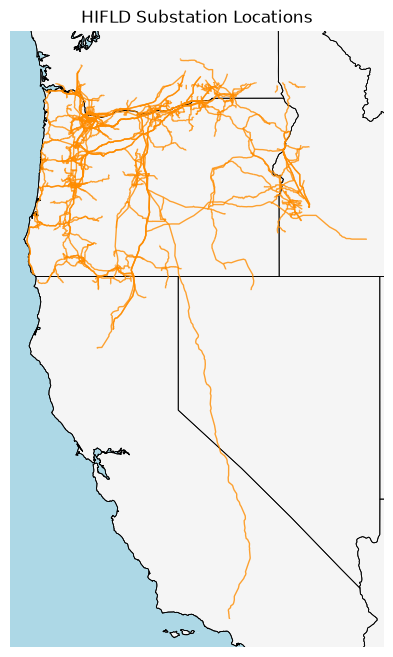

In [10]:
fig,ax = plt.subplots(figsize=(8, 8),subplot_kw={"projection": ccrs.PlateCarree()})

gdf = gpd.read_file(path)
gdf.plot(ax=ax, figsize=(9, 9), linewidth=1.0, color='darkorange', alpha=0.8)

# Basemap
ax.add_feature(
    cfeature.LAND,
    facecolor="whitesmoke"
)

ax.add_feature(
    cfeature.OCEAN,
    facecolor="lightblue"
)

ax.add_feature(
    cfeature.STATES,
    linewidth=0.6
)

ax.add_feature(
    cfeature.COASTLINE,
    linewidth=0.6
)

ax.set_title('HIFLD Substation Locations')
ax.set_axis_off()
plt.show()



In [4]:
import requests

url = (
    "https://services.arcgis.com/uUvqNMGPm7axC2dD/"
    "arcgis/rest/services/Transmission_Lines_OR/"
    "FeatureServer/0"
)

metadata = requests.get(
    url,
    params={"f": "json"}
).json()

for f in metadata["fields"]:
    print(f["name"])

OBJECTID
ID
TYPE
STATUS
NAICS_CODE
NAICS_DESC
SOURCE
SOURCEDATE
VAL_METHOD
VAL_DATE
OWNER
VOLTAGE
VOLT_CLASS
INFERRED
SUB_1
SUB_2
Shape__Length
